# Expected Loss, Capital Modeling & RAROC

## Business Context

A credit risk model that only predicts default probability is incomplete. The question a bank's credit committee actually asks is not *"will this borrower default?"* — it is *"if this borrower defaults, how much do we lose, and is the return worth the risk we are holding capital against?"*

This notebook answers that question by building the **Financial Intelligence Layer** of the AI Risk Decisioning System — the component that translates PD model output into the financial language of risk management:

| Component | Formula | What It Answers |
|-----------|---------|------------------|
| **Expected Loss (EL)** | PD × LGD × EAD | How much will we lose on average? |
| **Risk-Weighted Assets (RWA)** | EAD × Risk Weight | How much capital must we hold? |
| **Economic Capital (EC)** | RWA × Capital Ratio | What is the actual capital consumed? |
| **RAROC** | (Revenue − EL − Cost) / EC | Is this loan worth the risk? |

## Regulatory Context

Under **Basel III** (implemented in India via RBI's capital adequacy framework), banks must hold capital proportional to the risk of their loan portfolio. The IRB (Internal Ratings-Based) approach — which is what this notebook simulates — allows banks to use their own PD estimates to compute regulatory capital requirements, subject to model validation and supervisory approval.

**RAROC** (Risk-Adjusted Return on Capital) is the primary metric used by credit committees and portfolio managers to evaluate whether a lending decision creates or destroys shareholder value. A loan with RAROC above the hurdle rate (typically 12–15% for Indian banks) is value-accretive; below it, the bank is taking on risk it is not being compensated for.

## Assumptions (Documented for Audit)

In a live environment these parameters are calibrated to observed loss data. For this simulation, industry-standard assumptions are used and explicitly documented:

| Parameter | Value | Basis |
|-----------|-------|-------|
| LGD (unsecured retail) | 45% | Basel II foundation IRB floor for unsecured retail |
| LGD (secured) | 25% | Standard assumption for collateralised loans |
| EAD | AMT_CREDIT | Loan amount at origination |
| Risk Weight (Band 1–2) | 75% | Basel III retail IRB |
| Risk Weight (Band 3) | 100% | Standard IRB |
| Risk Weight (Band 4–5) | 150% | High-risk / sub-standard |
| Capital Ratio | 10.5% | RBI minimum CET1 + conservation buffer |
| Hurdle Rate (RAROC) | 14% | Indicative for Indian retail lending |
| Interest Rate (base) | 12% p.a. | Approximate Home Credit retail rate |
| Operating Cost Ratio | 3% of EAD | Industry approximation |

## Inputs
- `../01_data/processed/scorecard_output.csv` — scored dataset with PD, RISK_BAND, CREDIT_SCORE
- `../01_data/processed/X_test.csv` — original features for EAD (AMT_CREDIT)

## Outputs
- `../01_data/processed/el_capital_output.csv` — full dataset with EL, RWA, EC, RAROC per borrower
- `../04_financial_intelligence/portfolio_summary.csv` — portfolio-level risk-return summary by risk band

---
## 1. Setup and Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("../04_financial_intelligence", exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


---
## 2. Load Data and Define Parameters

In [5]:
# Load scored dataset from notebook 03
scored = pd.read_csv("../01_data/processed/scorecard_output.csv")
X_test = pd.read_csv("../01_data/processed/X_test.csv")

# Convert booleans
bool_cols = X_test.select_dtypes(include="bool").columns
X_test[bool_cols] = X_test[bool_cols].astype(int)

# Attach AMT_CREDIT as EAD proxy
scored = scored.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
scored["AMT_CREDIT"]       = X_test["AMT_CREDIT"]
scored["AMT_ANNUITY"]       = X_test["AMT_ANNUITY"] if "AMT_ANNUITY" in X_test.columns else np.nan

print(f"Portfolio size : {len(scored):,} loans")
print(f"Total exposure : ₹{scored['AMT_CREDIT'].sum():,.0f}")
print(f"Mean loan size : ₹{scored['AMT_CREDIT'].mean():,.0f}")
print(f"Actual default rate: {scored['ACTUAL_DEFAULT'].mean():.2%}")

Portfolio size : 61,503 loans
Total exposure : ₹36,521,034,381
Mean loan size : ₹593,809
Actual default rate: 8.05%


In [6]:
# ── MODEL PARAMETERS (documented assumptions) ────────────────────────────────

# Loss Given Default — Basel II foundation IRB floor for unsecured retail
LGD_UNSECURED = 0.45
LGD_SECURED   = 0.25
# Home Credit is predominantly unsecured consumer lending
LGD_DEFAULT   = LGD_UNSECURED

# Risk weights by risk band (Basel III IRB approach)
RISK_WEIGHTS = {1: 0.75, 2: 0.75, 3: 1.00, 4: 1.50, 5: 1.50}

# Capital ratio — RBI minimum CET1 (4.5%) + capital conservation buffer (2.5%) + extra buffer
CAPITAL_RATIO = 0.105

# Revenue and cost assumptions
INTEREST_RATE     = 0.12    # annual interest revenue as % of EAD
OPERATING_COST    = 0.03    # operating cost as % of EAD
HURDLE_RATE       = 0.14    # minimum acceptable RAROC (14%)

print("Parameters configured:")
print(f"  LGD (unsecured) : {LGD_DEFAULT:.0%}")
print(f"  Capital ratio   : {CAPITAL_RATIO:.1%}")
print(f"  Interest rate   : {INTEREST_RATE:.0%} p.a.")
print(f"  Hurdle rate     : {HURDLE_RATE:.0%}")

Parameters configured:
  LGD (unsecured) : 45%
  Capital ratio   : 10.5%
  Interest rate   : 12% p.a.
  Hurdle rate     : 14%


---
## 3. Expected Loss (EL)

### Formula

$$EL = PD \times LGD \times EAD$$

Where:
- **PD** = Probability of Default (from XGBoost model, notebook 02)
- **LGD** = Loss Given Default — the fraction of EAD lost if default occurs (45% for unsecured)
- **EAD** = Exposure at Default — the outstanding loan amount at the time of default

EL is the **average loss** the bank expects to incur on a loan over its lifetime. It is not a worst-case figure — that is Unexpected Loss (UL), which capital is held against. EL should be **priced into the interest rate** as a cost of lending.

### Interpretation

If EL = ₹5,000 on a ₹100,000 loan, the bank expects to lose ₹5,000 on average. It should charge at minimum 5% in its interest rate to cover this cost before earning any return.

In [7]:
# ── EXPECTED LOSS ─────────────────────────────────────────────────────────────
scored["EAD"] = scored["AMT_CREDIT"]
scored["LGD"] = LGD_DEFAULT
scored["EL"]  = scored["PD"] * scored["LGD"] * scored["EAD"]
scored["EL_RATE"] = scored["PD"] * scored["LGD"]   # EL as % of EAD

print("EXPECTED LOSS SUMMARY")
print("=" * 55)
print(f"Total portfolio EAD  : ₹{scored['EAD'].sum():>15,.0f}")
print(f"Total Expected Loss  : ₹{scored['EL'].sum():>15,.0f}")
print(f"Portfolio EL rate    :  {scored['EL'].sum() / scored['EAD'].sum():>14.2%}")
print(f"Mean EL per loan     : ₹{scored['EL'].mean():>15,.0f}")
print(f"Median EL per loan   : ₹{scored['EL'].median():>15,.0f}")
print("=" * 55)

EXPECTED LOSS SUMMARY
Total portfolio EAD  : ₹ 36,521,034,381
Total Expected Loss  : ₹  6,424,773,807
Portfolio EL rate    :          17.59%
Mean EL per loan     : ₹        104,463
Median EL per loan   : ₹         83,952


In [8]:
# EL by risk band
el_by_band = scored.groupby("RISK_BAND").agg(
    Loans         = ("EAD",     "count"),
    Total_EAD     = ("EAD",     "sum"),
    Mean_PD       = ("PD",      "mean"),
    Total_EL      = ("EL",      "sum"),
    Mean_EL_Rate  = ("EL_RATE", "mean")
).reset_index()

el_by_band["EL_as_pct_EAD"] = el_by_band["Total_EL"] / el_by_band["Total_EAD"]

band_labels = {1: "Very Low", 2: "Low", 3: "Medium", 4: "High", 5: "Very High"}
el_by_band["Risk Category"] = el_by_band["RISK_BAND"].map(band_labels)

display_cols = ["RISK_BAND", "Risk Category", "Loans", "Total_EAD", "Mean_PD", "Total_EL", "EL_as_pct_EAD"]
el_display = el_by_band[display_cols].copy()
el_display["Total_EAD"]      = el_display["Total_EAD"].apply(lambda x: f"₹{x:,.0f}")
el_display["Total_EL"]       = el_display["Total_EL"].apply(lambda x: f"₹{x:,.0f}")
el_display["Mean_PD"]        = el_display["Mean_PD"].apply(lambda x: f"{x:.2%}")
el_display["EL_as_pct_EAD"]  = el_display["EL_as_pct_EAD"].apply(lambda x: f"{x:.2%}")

print("EXPECTED LOSS BY RISK BAND")
print("=" * 80)
print(el_display.to_string(index=False))
print("=" * 80)

EXPECTED LOSS BY RISK BAND
 RISK_BAND Risk Category  Loans       Total_EAD Mean_PD       Total_EL EL_as_pct_EAD
         1      Very Low    245    ₹188,193,438   3.65%     ₹2,916,940         1.55%
         2           Low   1786  ₹1,128,029,638   7.94%    ₹40,228,328         3.57%
         3        Medium   8925  ₹5,691,449,426  15.53%   ₹398,254,575         7.00%
         4          High  16542 ₹10,417,205,606  27.46% ₹1,284,541,084        12.33%
         5     Very High  34005 ₹19,096,156,274  55.70% ₹4,698,832,879        24.61%


---
## 4. Risk-Weighted Assets (RWA) and Economic Capital

### Why Capital Matters

Expected Loss is covered by pricing (interest rate). But losses are not deterministic — actual losses can exceed EL in a bad year. The difference between actual loss and EL is the **Unexpected Loss (UL)**, and this is what **capital** exists to absorb.

Under Basel III, capital requirements are expressed through **Risk-Weighted Assets**:

$$RWA = EAD \times \text{Risk Weight}$$

$$\text{Economic Capital} = RWA \times \text{Capital Ratio}$$

A Band 5 borrower attracts a 150% risk weight — meaning ₹100 of exposure consumes ₹150 of RWA and ₹15.75 of capital. A Band 1 borrower at 75% consumes only ₹7.88. **Capital is not free** — it has a cost equal to the return shareholders expect on it. This is why high-risk borrowers must be charged higher rates, not just to cover EL, but to earn a sufficient return on the capital they consume.

In [9]:
# ── RISK-WEIGHTED ASSETS AND ECONOMIC CAPITAL ─────────────────────────────────
scored["RISK_WEIGHT"]  = scored["RISK_BAND"].map(RISK_WEIGHTS)
scored["RWA"]          = scored["EAD"] * scored["RISK_WEIGHT"]
scored["ECON_CAPITAL"] = scored["RWA"] * CAPITAL_RATIO

print("CAPITAL SUMMARY")
print("=" * 55)
print(f"Total EAD              : ₹{scored['EAD'].sum():>15,.0f}")
print(f"Total RWA              : ₹{scored['RWA'].sum():>15,.0f}")
print(f"Total Economic Capital : ₹{scored['ECON_CAPITAL'].sum():>15,.0f}")
print(f"Capital / EAD ratio    :  {scored['ECON_CAPITAL'].sum() / scored['EAD'].sum():>14.2%}")
print("=" * 55)

# Capital by risk band
cap_by_band = scored.groupby("RISK_BAND").agg(
    Total_EAD     = ("EAD",          "sum"),
    Total_RWA     = ("RWA",          "sum"),
    Total_Capital = ("ECON_CAPITAL", "sum")
).reset_index()
cap_by_band["Capital_Intensity"] = cap_by_band["Total_Capital"] / cap_by_band["Total_EAD"]
cap_by_band["Risk Category"] = cap_by_band["RISK_BAND"].map(band_labels)

cap_display = cap_by_band[["RISK_BAND", "Risk Category", "Total_EAD", "Total_RWA",
                            "Total_Capital", "Capital_Intensity"]].copy()
for col in ["Total_EAD", "Total_RWA", "Total_Capital"]:
    cap_display[col] = cap_display[col].apply(lambda x: f"₹{x:,.0f}")
cap_display["Capital_Intensity"] = cap_display["Capital_Intensity"].apply(lambda x: f"{x:.2%}")

print("\nCAPITAL CONSUMPTION BY RISK BAND")
print("=" * 80)
print(cap_display.to_string(index=False))
print("=" * 80)

CAPITAL SUMMARY
Total EAD              : ₹ 36,521,034,381
Total RWA              : ₹ 50,948,659,551
Total Economic Capital : ₹  5,349,609,253
Capital / EAD ratio    :          14.65%

CAPITAL CONSUMPTION BY RISK BAND
 RISK_BAND Risk Category       Total_EAD       Total_RWA  Total_Capital Capital_Intensity
         1      Very Low    ₹188,193,438    ₹141,145,078    ₹14,820,233             7.88%
         2           Low  ₹1,128,029,638    ₹846,022,229    ₹88,832,334             7.88%
         3        Medium  ₹5,691,449,426  ₹5,691,449,426   ₹597,602,190            10.50%
         4          High ₹10,417,205,606 ₹15,625,808,408 ₹1,640,709,883            15.75%
         5     Very High ₹19,096,156,274 ₹28,644,234,410 ₹3,007,644,613            15.75%


---
## 5. RAROC — Risk-Adjusted Return on Capital

### The Decisive Metric

$$RAROC = \frac{\text{Revenue} - \text{Expected Loss} - \text{Operating Cost}}{\text{Economic Capital}}$$

RAROC answers the fundamental credit question: **is this loan worth taking?**

- If RAROC > Hurdle Rate → the loan **creates value** for shareholders
- If RAROC < Hurdle Rate → the loan **destroys value** — the bank is not being paid enough for the risk and capital consumed
- If RAROC < 0 → the loan is expected to lose money outright

Banks do not make lending decisions on PD alone. A high-PD borrower can still be value-accretive if they are charged a sufficiently high interest rate. A low-PD borrower can be value-destructive if the loan is too large relative to the return it generates. **RAROC is the correct decision criterion.**

### Risk-Based Pricing Adjustment

For this simulation, a base interest rate of 12% is applied uniformly. In the Strategy Simulator (notebook 05), interest rates will be adjusted per risk band to model risk-based pricing.

In [10]:
# ── RAROC CALCULATION ─────────────────────────────────────────────────────────
scored["REVENUE"]      = scored["EAD"] * INTEREST_RATE
scored["OPEX"]         = scored["EAD"] * OPERATING_COST
scored["NET_INCOME"]   = scored["REVENUE"] - scored["EL"] - scored["OPEX"]

# Avoid division by zero for zero-capital edge cases
scored["RAROC"] = np.where(
    scored["ECON_CAPITAL"] > 0,
    scored["NET_INCOME"] / scored["ECON_CAPITAL"],
    0
)

# Value decision
scored["VALUE_DECISION"] = np.where(
    scored["RAROC"] >= HURDLE_RATE, "Value Accretive",
    np.where(scored["RAROC"] >= 0,  "Marginal",
                                     "Value Destructive")
)

value_summary = scored["VALUE_DECISION"].value_counts()
print("RAROC — PORTFOLIO VALUE SUMMARY")
print("=" * 55)
print(f"Mean RAROC (portfolio)    : {scored['RAROC'].mean():.2%}")
print(f"Median RAROC              : {scored['RAROC'].median():.2%}")
print(f"Hurdle rate               : {HURDLE_RATE:.0%}")
print("─" * 55)
for decision, count in value_summary.items():
    print(f"  {decision:<25}: {count:>6,} loans ({count/len(scored):.1%})")
print("=" * 55)

RAROC — PORTFOLIO VALUE SUMMARY
Mean RAROC (portfolio)    : -56.98%
Median RAROC              : -52.05%
Hurdle rate               : 14%
───────────────────────────────────────────────────────
  Value Destructive        : 50,547 loans (82.2%)
  Value Accretive          :  7,485 loans (12.2%)
  Marginal                 :  3,471 loans (5.6%)


In [11]:
# RAROC by risk band
raroc_by_band = scored.groupby("RISK_BAND").agg(
    Loans          = ("EAD",            "count"),
    Mean_PD        = ("PD",             "mean"),
    Total_Revenue  = ("REVENUE",        "sum"),
    Total_EL       = ("EL",             "sum"),
    Total_Opex     = ("OPEX",           "sum"),
    Total_Capital  = ("ECON_CAPITAL",   "sum"),
    Mean_RAROC     = ("RAROC",          "mean")
).reset_index()

raroc_by_band["Portfolio_RAROC"] = (
    (raroc_by_band["Total_Revenue"] - raroc_by_band["Total_EL"] - raroc_by_band["Total_Opex"])
    / raroc_by_band["Total_Capital"]
)
raroc_by_band["Risk Category"] = raroc_by_band["RISK_BAND"].map(band_labels)
raroc_by_band["Vs Hurdle"]     = raroc_by_band["Portfolio_RAROC"].apply(
    lambda x: f"+{x - HURDLE_RATE:.1%}" if x >= HURDLE_RATE else f"{x - HURDLE_RATE:.1%}"
)

raroc_display = raroc_by_band[["RISK_BAND", "Risk Category", "Loans",
                                "Mean_PD", "Portfolio_RAROC", "Vs Hurdle"]].copy()
raroc_display["Mean_PD"]        = raroc_display["Mean_PD"].apply(lambda x: f"{x:.2%}")
raroc_display["Portfolio_RAROC"]= raroc_display["Portfolio_RAROC"].apply(lambda x: f"{x:.2%}")

print("RAROC BY RISK BAND")
print("=" * 70)
print(raroc_display.to_string(index=False))
print("=" * 70)
print(f"\nHurdle rate: {HURDLE_RATE:.0%} | Positive = value accretive at uniform 12% rate")

RAROC BY RISK BAND
 RISK_BAND Risk Category  Loans Mean_PD Portfolio_RAROC Vs Hurdle
         1      Very Low    245   3.65%          94.60%    +80.6%
         2           Low   1786   7.94%          69.00%    +55.0%
         3        Medium   8925  15.53%          19.07%     +5.1%
         4          High  16542  27.46%         -21.15%    -35.1%
         5     Very High  34005  55.70%         -99.09%   -113.1%

Hurdle rate: 14% | Positive = value accretive at uniform 12% rate


---
## 6. Visualisations — The Full Financial Picture

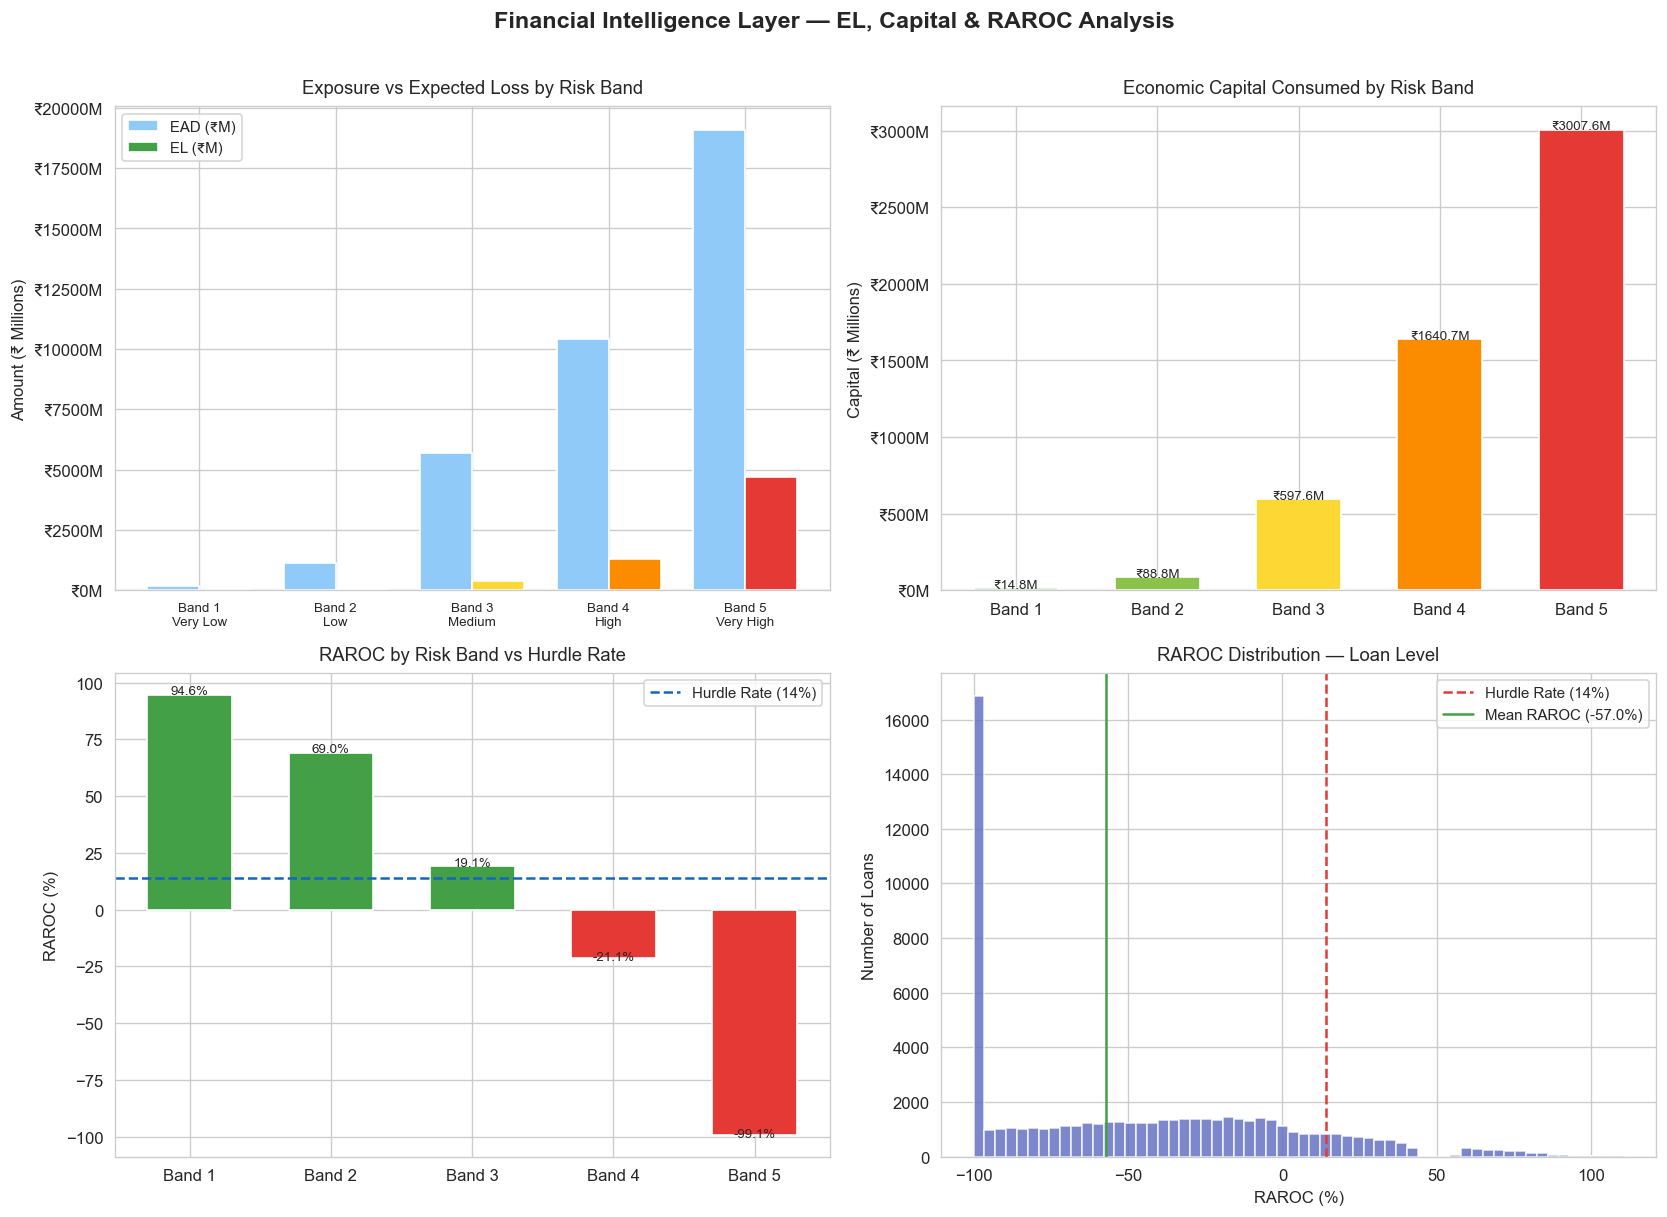

In [12]:
band_colors = ["#43A047", "#8BC34A", "#FDD835", "#FB8C00", "#E53935"]
bands = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: EAD vs EL by risk band ──
ax = axes[0, 0]
ead_vals = [el_by_band.loc[el_by_band["RISK_BAND"]==b, "Total_EAD"].values[0] / 1e6 for b in bands]
el_vals  = [el_by_band.loc[el_by_band["RISK_BAND"]==b, "Total_EL"].values[0]  / 1e6 for b in bands]
x = np.arange(5)
w = 0.38
bars1 = ax.bar(x - w/2, ead_vals, w, label="EAD (₹M)",  color="#90CAF9", edgecolor="white")
bars2 = ax.bar(x + w/2, el_vals,  w, label="EL (₹M)",   color=band_colors, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([f"Band {b}\n{band_labels[b]}" for b in bands], fontsize=8)
ax.set_title("Exposure vs Expected Loss by Risk Band", fontsize=11, pad=8)
ax.set_ylabel("Amount (₹ Millions)")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"₹{x:.0f}M"))

# ── Plot 2: Capital consumption by band ──
ax = axes[0, 1]
cap_vals = [cap_by_band.loc[cap_by_band["RISK_BAND"]==b, "Total_Capital"].values[0] / 1e6 for b in bands]
bars = ax.bar([f"Band {b}" for b in bands], cap_vals,
              color=band_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, cap_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"₹{val:.1f}M", ha="center", fontsize=8)
ax.set_title("Economic Capital Consumed by Risk Band", fontsize=11, pad=8)
ax.set_ylabel("Capital (₹ Millions)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"₹{x:.0f}M"))

# ── Plot 3: RAROC by band vs hurdle rate ──
ax = axes[1, 0]
raroc_vals = [raroc_by_band.loc[raroc_by_band["RISK_BAND"]==b, "Portfolio_RAROC"].values[0] * 100
              for b in bands]
bar_colors_raroc = ["#43A047" if r >= HURDLE_RATE * 100 else "#E53935" for r in raroc_vals]
bars = ax.bar([f"Band {b}" for b in bands], raroc_vals,
              color=bar_colors_raroc, edgecolor="white", width=0.6)
ax.axhline(HURDLE_RATE * 100, color="#1565C0", linestyle="--", lw=1.5,
           label=f"Hurdle Rate ({HURDLE_RATE:.0%})")
for bar, val in zip(bars, raroc_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.3 if val >= 0 else -1.2),
            f"{val:.1f}%", ha="center", fontsize=8)
ax.set_title("RAROC by Risk Band vs Hurdle Rate", fontsize=11, pad=8)
ax.set_ylabel("RAROC (%)")
ax.legend(fontsize=9)

# ── Plot 4: RAROC distribution across all loans ──
ax = axes[1, 1]
raroc_clipped = scored["RAROC"].clip(-1, 2) * 100
ax.hist(raroc_clipped, bins=60, color="#5C6BC0", edgecolor="white", alpha=0.8)
ax.axvline(HURDLE_RATE * 100, color="#E53935", linestyle="--", lw=1.5,
           label=f"Hurdle Rate ({HURDLE_RATE:.0%})")
ax.axvline(scored["RAROC"].mean() * 100, color="#43A047", linestyle="-", lw=1.5,
           label=f"Mean RAROC ({scored['RAROC'].mean():.1%})")
ax.set_xlabel("RAROC (%)", fontsize=10)
ax.set_ylabel("Number of Loans", fontsize=10)
ax.set_title("RAROC Distribution — Loan Level", fontsize=11, pad=8)
ax.legend(fontsize=9)

plt.suptitle("Financial Intelligence Layer — EL, Capital & RAROC Analysis",
             fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 7. Portfolio Risk-Return Summary

This is the table a credit committee would review to understand where the portfolio stands across risk, return, and capital dimensions simultaneously — the full picture in one view.

In [13]:
portfolio_summary = scored.groupby("RISK_BAND").agg(
    Risk_Category  = ("RISK_BAND",     lambda x: band_labels[x.iloc[0]]),
    Loans          = ("EAD",           "count"),
    Total_EAD      = ("EAD",           "sum"),
    Mean_PD        = ("PD",            "mean"),
    Total_EL       = ("EL",            "sum"),
    EL_Rate        = ("EL_RATE",       "mean"),
    Total_RWA      = ("RWA",           "sum"),
    Total_Capital  = ("ECON_CAPITAL",  "sum"),
    Total_Revenue  = ("REVENUE",       "sum"),
    Total_NetIncome= ("NET_INCOME",    "sum"),
).reset_index()

portfolio_summary["Portfolio_RAROC"] = (
    portfolio_summary["Total_NetIncome"] / portfolio_summary["Total_Capital"]
)
portfolio_summary["NPA_Proxy"] = portfolio_summary["Total_EL"] / portfolio_summary["Total_EAD"]

# Grand total row
total_row = pd.DataFrame([{
    "RISK_BAND"       : "ALL",
    "Risk_Category"   : "Portfolio Total",
    "Loans"           : len(scored),
    "Total_EAD"       : scored["EAD"].sum(),
    "Mean_PD"         : scored["PD"].mean(),
    "Total_EL"        : scored["EL"].sum(),
    "EL_Rate"         : scored["EL_RATE"].mean(),
    "Total_RWA"       : scored["RWA"].sum(),
    "Total_Capital"   : scored["ECON_CAPITAL"].sum(),
    "Total_Revenue"   : scored["REVENUE"].sum(),
    "Total_NetIncome" : scored["NET_INCOME"].sum(),
    "Portfolio_RAROC" : scored["NET_INCOME"].sum() / scored["ECON_CAPITAL"].sum(),
    "NPA_Proxy"       : scored["EL"].sum() / scored["EAD"].sum(),
}])

summary_full = pd.concat([portfolio_summary, total_row], ignore_index=True)

# Format for display
summary_display = summary_full[["RISK_BAND", "Risk_Category", "Loans",
                                  "Mean_PD", "EL_Rate", "Portfolio_RAROC", "NPA_Proxy"]].copy()
summary_display["Mean_PD"]         = summary_display["Mean_PD"].apply(lambda x: f"{float(x):.2%}")
summary_display["EL_Rate"]         = summary_display["EL_Rate"].apply(lambda x: f"{float(x):.2%}")
summary_display["Portfolio_RAROC"] = summary_display["Portfolio_RAROC"].apply(lambda x: f"{float(x):.2%}")
summary_display["NPA_Proxy"]       = summary_display["NPA_Proxy"].apply(lambda x: f"{float(x):.2%}")

print("PORTFOLIO RISK-RETURN SUMMARY")
print("=" * 75)
print(summary_display.to_string(index=False))
print("=" * 75)

# Save portfolio summary
portfolio_summary.to_csv("../04_financial_intelligence/portfolio_summary.csv", index=False)
print("\nPortfolio summary saved to ../04_financial_intelligence/portfolio_summary.csv")

PORTFOLIO RISK-RETURN SUMMARY
RISK_BAND   Risk_Category  Loans Mean_PD EL_Rate Portfolio_RAROC NPA_Proxy
        1        Very Low    245   3.65%   1.64%          94.60%     1.55%
        2             Low   1786   7.94%   3.57%          69.00%     3.57%
        3          Medium   8925  15.53%   6.99%          19.07%     7.00%
        4            High  16542  27.46%  12.36%         -21.15%    12.33%
        5       Very High  34005  55.70%  25.07%         -99.09%    24.61%
      ALL Portfolio Total  61503  40.68%  18.31%         -58.66%    17.59%

Portfolio summary saved to ../04_financial_intelligence/portfolio_summary.csv


---
## 8. Marginal RAROC — Loan-Level Decision Signal

At the individual loan level, RAROC determines whether to approve, reprice, or decline. This section flags each loan in the test portfolio against the hurdle rate — simulating what the Decision Engine (notebook 05) will do at origination.

In [14]:
decision_summary = scored["VALUE_DECISION"].value_counts().reset_index()
decision_summary.columns = ["Decision", "Loan Count"]
decision_summary["% of Portfolio"] = (decision_summary["Loan Count"] / len(scored) * 100).round(1)
decision_summary["Total EAD"] = [
    scored.loc[scored["VALUE_DECISION"] == d, "EAD"].sum()
    for d in decision_summary["Decision"]
]
decision_summary["Total EL"] = [
    scored.loc[scored["VALUE_DECISION"] == d, "EL"].sum()
    for d in decision_summary["Decision"]
]
decision_summary["Avg RAROC"] = [
    scored.loc[scored["VALUE_DECISION"] == d, "RAROC"].mean()
    for d in decision_summary["Decision"]
]

for col in ["Total EAD", "Total EL"]:
    decision_summary[col] = decision_summary[col].apply(lambda x: f"₹{x:,.0f}")
decision_summary["Avg RAROC"] = decision_summary["Avg RAROC"].apply(lambda x: f"{x:.2%}")

print("LOAN-LEVEL VALUE DECISION SUMMARY")
print("=" * 75)
print(decision_summary.to_string(index=False))
print("=" * 75)
print(f"\nNote: 'Marginal' loans are candidates for risk-based repricing in notebook 05.")
print(f"      'Value Destructive' loans would be declined under a strict RAROC policy.")

LOAN-LEVEL VALUE DECISION SUMMARY
         Decision  Loan Count  % of Portfolio       Total EAD       Total EL Avg RAROC
Value Destructive       50547            82.2 ₹29,513,361,879 ₹5,983,373,963   -75.60%
  Value Accretive        7485            12.2  ₹4,781,533,838   ₹256,952,809    39.17%
         Marginal        3471             5.6  ₹2,226,138,664   ₹184,447,035     6.86%

Note: 'Marginal' loans are candidates for risk-based repricing in notebook 05.
      'Value Destructive' loans would be declined under a strict RAROC policy.


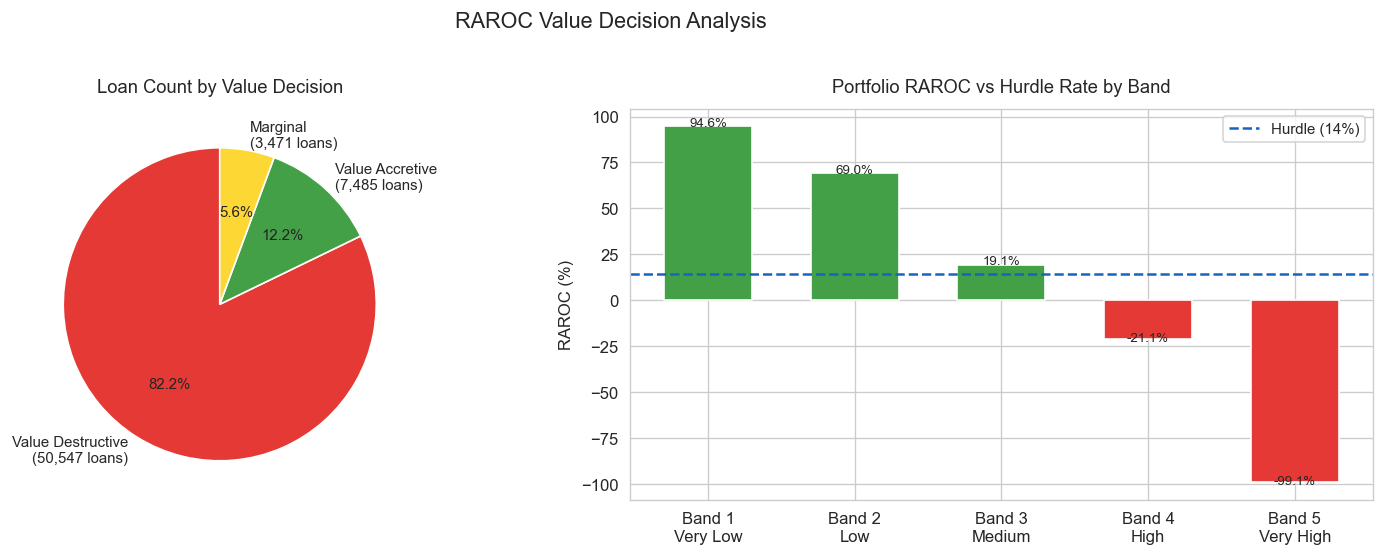

In [15]:
# Visualise value decision breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

decision_colors = {
    "Value Accretive"   : "#43A047",
    "Marginal"          : "#FDD835",
    "Value Destructive" : "#E53935"
}

counts = scored["VALUE_DECISION"].value_counts()
colors = [decision_colors.get(d, "#90A4AE") for d in counts.index]

# Pie: loan count
axes[0].pie(
    counts.values,
    labels=[f"{d}\n({v:,} loans)" for d, v in zip(counts.index, counts.values)],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 9}
)
axes[0].set_title("Loan Count by Value Decision", fontsize=11, pad=10)

# Bar: average RAROC by risk band
raroc_band_vals = [raroc_by_band.loc[raroc_by_band["RISK_BAND"]==b, "Portfolio_RAROC"].values[0] * 100
                   for b in bands]
bar_c = ["#43A047" if r >= HURDLE_RATE * 100 else "#E53935" for r in raroc_band_vals]
axes[1].bar([f"Band {b}\n{band_labels[b]}" for b in bands],
            raroc_band_vals, color=bar_c, edgecolor="white", width=0.6)
axes[1].axhline(HURDLE_RATE * 100, color="#1565C0", linestyle="--", lw=1.5,
                label=f"Hurdle ({HURDLE_RATE:.0%})")
axes[1].set_ylabel("RAROC (%)")
axes[1].set_title("Portfolio RAROC vs Hurdle Rate by Band", fontsize=11, pad=10)
axes[1].legend(fontsize=9)
for i, val in enumerate(raroc_band_vals):
    axes[1].text(i, val + (0.3 if val >= 0 else -1.2),
                 f"{val:.1f}%", ha="center", fontsize=8)

plt.suptitle("RAROC Value Decision Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Save Final Output

In [16]:
output_cols = [
    "ACTUAL_DEFAULT", "PD", "RISK_BAND", "CREDIT_SCORE", "RISK_GRADE",
    "EAD", "LGD", "EL", "EL_RATE",
    "RISK_WEIGHT", "RWA", "ECON_CAPITAL",
    "REVENUE", "OPEX", "NET_INCOME", "RAROC",
    "VALUE_DECISION"
]

final_output = scored[output_cols].copy()
final_output.to_csv("../01_data/processed/el_capital_output.csv", index=False)

print(f"Final output saved: {final_output.shape[0]:,} rows × {final_output.shape[1]} columns")
print("File: ../01_data/processed/el_capital_output.csv")
print("\nColumn summary:")
print(final_output[output_cols[-9:]].describe().round(4))

Final output saved: 61,503 rows × 17 columns
File: ../01_data/processed/el_capital_output.csv

Column summary:
          EL_RATE  RISK_WEIGHT           RWA  ECON_CAPITAL      REVENUE  \
count  61503.0000   61503.0000  6.150300e+04    61503.0000   61503.0000   
mean       0.1831       1.4027  8.283931e+05    86981.2733   71257.0789   
std        0.0919       0.2130  5.443219e+05    57153.8035   46627.6135   
min        0.0030       0.7500  5.730750e+04     6017.2875    9169.2000   
25%        0.1081       1.5000  4.043250e+05    42454.1250   32400.0000   
50%        0.1720       1.5000  7.222432e+05    75835.5412   61190.6400   
75%        0.2511       1.5000  1.136258e+06   119307.0769   97038.0000   
max        0.4306       1.5000  2.781000e+06   292005.0000  222480.0000   

             OPEX   NET_INCOME       RAROC  
count  61503.0000   61503.0000  61503.0000  
mean   17814.2697  -51019.9618     -0.5698  
std    11656.9034   63179.2489      0.6185  
min     2292.3000 -553022.3793   

---
## 10. Summary — Financial Intelligence Layer

### What This Notebook Demonstrates

This notebook moves the AI Risk Decisioning System from **prediction** to **financial decision-making** — the distinction that separates a data science project from a risk management system.

| Layer | Notebook | Output |
|-------|----------|--------|
| Data | 01 | Cleaned features |
| PD Model | 02 | Probability of Default per borrower |
| Scorecard | 03 | Interpretable credit score per borrower |
| **Financial Intelligence** | **04 (this)** | **EL, RWA, Capital, RAROC per borrower** |
| Strategy | 05 | Portfolio outcomes under 3 lending strategies |
| Stress Testing | 06 | Capital impact under adverse scenarios |

### Key Findings (Update with actual values after running)

- **Portfolio EL rate**: [*run to populate*] — the average cost of credit risk across the portfolio
- **Capital intensity**: [*run to populate*] — capital held as a % of total exposure
- **Bands 4–5 RAROC**: [*run to populate*] — whether high-risk borrowers are value accretive at the 12% base rate
- **% value destructive loans**: [*run to populate*] — loans that would be declined under strict RAROC policy

### Critical Insight: PD ≠ Decision

The most important finding from this notebook is that **PD alone is not a sufficient decision criterion**. A Band 3 borrower (PD 10–20%) may have a higher RAROC than a Band 1 borrower if the loan size is smaller, the rate is higher, or the capital consumption is proportionally lower. This is why sophisticated lenders use RAROC — not PD cutoffs — as their primary approval criterion.

This distinction is what the Strategy Simulator in notebook 05 will test directly.

### Limitations

- **LGD is assumed constant** at 45% across all loans. In practice, LGD varies by collateral type, loan seniority, and recovery environment. A more sophisticated model would use a separate LGD regression.
- **EAD is loan amount at origination** — does not account for undrawn commitments or early repayment. For revolving credit, EAD estimation requires a Credit Conversion Factor (CCF).
- **Interest rate is uniform** at 12% — risk-based pricing is modelled in notebook 05.
- **Capital ratio is static** — in practice, ICAAP requires dynamic capital assessment including stress buffers.

### Next Step

`el_capital_output.csv` feeds into `05_strategy_simulator.ipynb` where three lending strategies (aggressive, conservative, risk-based pricing) are simulated against this portfolio to evaluate the risk-return trade-off under each policy.